# Lib

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from collections import Counter
from scipy.stats import linregress

import warnings
warnings.filterwarnings('ignore')

# Data

In [2]:
# Load Labels
df_target = pd.read_csv("../../data/github_social_network/musae_git_target.csv")
df_target.columns = df_target.columns.str.strip().str.lower().str.replace(" ", "_")

# Load Edges
df_edges = pd.read_csv("../../data/github_social_network/musae_git_edges.csv")
df_edges.columns = df_edges.columns.str.strip().str.lower().str.replace(" ", "_")

# Load Features
with open("../../data/github_social_network/musae_git_features.json", "r") as f:
    features_json = json.load(f)

In [3]:
print(f"Labels: {len(df_target)}")
print(f"Edges: {len(df_edges)}")
print(f"Features: {len(features_json)}")

Labels: 37700
Edges: 289003
Features: 37700


# Graph

In [4]:
G = nx.from_pandas_edgelist(
    df_edges, source="id_1", target="id_2", create_using=nx.DiGraph()
)

# Basic Information

In [5]:
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)
avg_degree = np.mean([deg for _, deg in G.degree()])

print(f"Number of Nodes : {n_nodes}")
print(f"Number of Edges : {n_edges}")
print(f"Directed Graph  : {G.is_directed()}")
print(f"Graph Density   : {density:.10f}")
print(f"Average Degree  : {avg_degree:.2f}")

Number of Nodes : 37700
Number of Edges : 289003
Directed Graph  : True
Graph Density   : 0.0002033439
Average Degree  : 15.33


# In-degress vs Out-degree

In [6]:
# In-degree = followers
in_degree_dict = dict(G.in_degree())

# Out-degree = following
out_degree_dict = dict(G.out_degree())

df_degree = pd.DataFrame(
    {
        "node_id": list(in_degree_dict.keys()),
        "in_degree": list(in_degree_dict.values()),
        "out_degree": list(out_degree_dict.values()),
    }
)

df_degree.head()

,node_id,in_degree,out_degree
0,0,0,1
1,23977,23,9
2,1,0,8
3,34526,1,1
4,2370,4,36


# Top developers by followers

In [7]:
top_followers = df_degree.sort_values(by="in_degree", ascending=False).reset_index(drop=True).head(10)
top_followers

,node_id,in_degree,out_degree
0,31890,7470,1988
1,35773,2401,923
2,36652,2285,58
3,18163,1858,66
4,19222,1499,1459
5,36628,1477,30
6,35008,1472,99
7,3712,884,380
8,13638,858,1610
9,30002,819,236


# Top active developers

In [8]:
top_following = df_degree.sort_values(by="out_degree", ascending=False).reset_index(drop=True).head(10)
top_following

,node_id,in_degree,out_degree
0,27803,276,6809
1,31890,7470,1988
2,13638,858,1610
3,19222,1499,1459
4,9051,419,1378
5,2078,73,1295
6,7027,261,1224
7,10001,419,1149
8,5629,205,1111
9,73,182,1085


# Degree distribution

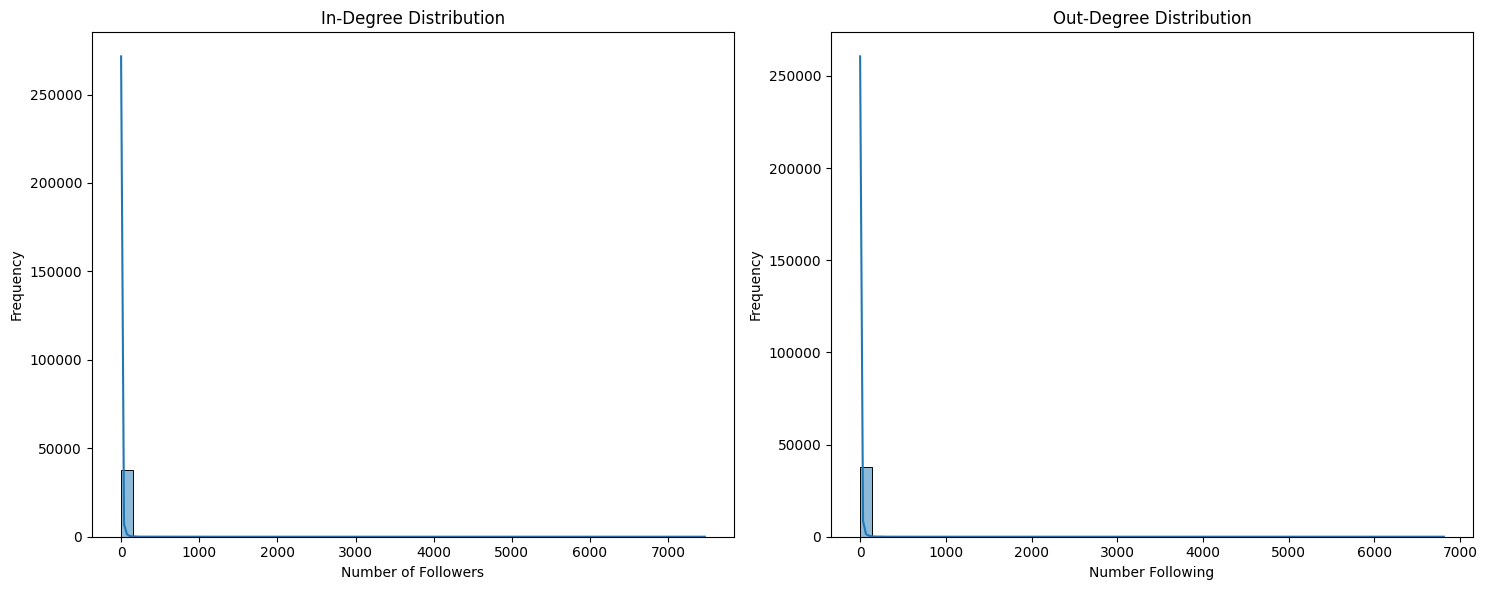

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# In-degree distribution
sns.histplot(df_degree["in_degree"], bins=50, kde=True, ax=axes[0])

axes[0].set_title("In-Degree Distribution")
axes[0].set_xlabel("Number of Followers")
axes[0].set_ylabel("Frequency")

# Out-degree distribution
sns.histplot(df_degree["out_degree"], bins=50, kde=True, ax=axes[1])

axes[1].set_title("Out-Degree Distribution")
axes[1].set_xlabel("Number Following")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Heavy-tail degree distribution

In [10]:
# Degree sequence
degree_sequence = sorted([d for _, d in G.degree()], reverse=True)

# Degree count
degree_count = Counter(degree_sequence)
deg, cnt = zip(*degree_count.items())

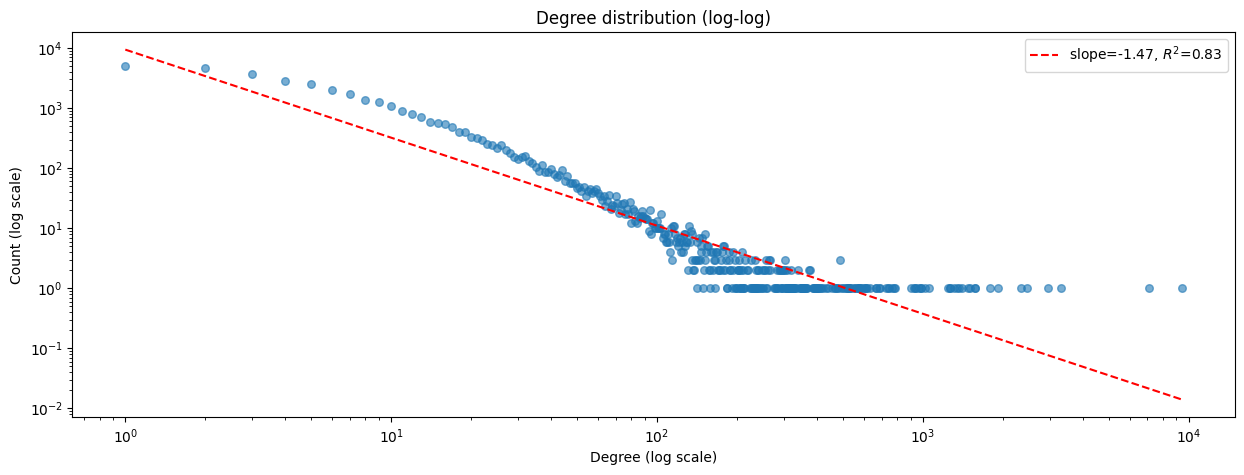

In [14]:
# Log-log plot and power-law fit
deg_list = np.array(deg)
cnt_list = np.array(cnt)
mask = cnt_list > 0
deg_list = deg_list[mask]
cnt_list = cnt_list[mask]

plt.figure(figsize=(15,5))
plt.scatter(deg_list, cnt_list, alpha=0.6, s=30)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Degree (log scale)')
plt.ylabel('Count (log scale)')
plt.title('Degree distribution (log-log)')

# Linear regression on log-log to estimate power-law exponent
log_deg = np.log10(deg_list)
log_cnt = np.log10(cnt_list)
slope, intercept, r_value, p_value, std_err = linregress(log_deg, log_cnt)
x_fit = np.linspace(log_deg.min(), log_deg.max(), 100)
y_fit = intercept + slope * x_fit
plt.plot(10**x_fit, 10**y_fit, color='red', linestyle='--', label=f'slope={slope:.2f}, $R^2$={r_value**2:.2f}')
plt.legend()
plt.show()


In [12]:
print(f'Power-law fit slope : {slope:.3f}')
print(f"End=r^2             : {r_value**2:.3f}")

Power-law fit slope : -1.466
End=r^2             : 0.826


# Connected component analysis

In [13]:
# Weakly connected components
weak_components = list(nx.weakly_connected_components(G))
print(f"Weakly Connected Components: {len(weak_components)}")
largest_weak_cc = max(weak_components, key=len)
print(f"Largest Weakly Connected Component Size: {len(largest_weak_cc)}")
print()
# Strongly connected components
strong_components = list(nx.strongly_connected_components(G))
print(f"Strongly Connected Components: {len(strong_components)}")
largest_strong_cc = max(strong_components, key=len)
print(f"Largest Strongly Connected Component Size: {len(largest_strong_cc)}")

Weakly Connected Components: 1
Largest Weakly Connected Component Size: 37700

Strongly Connected Components: 37700
Largest Strongly Connected Component Size: 1


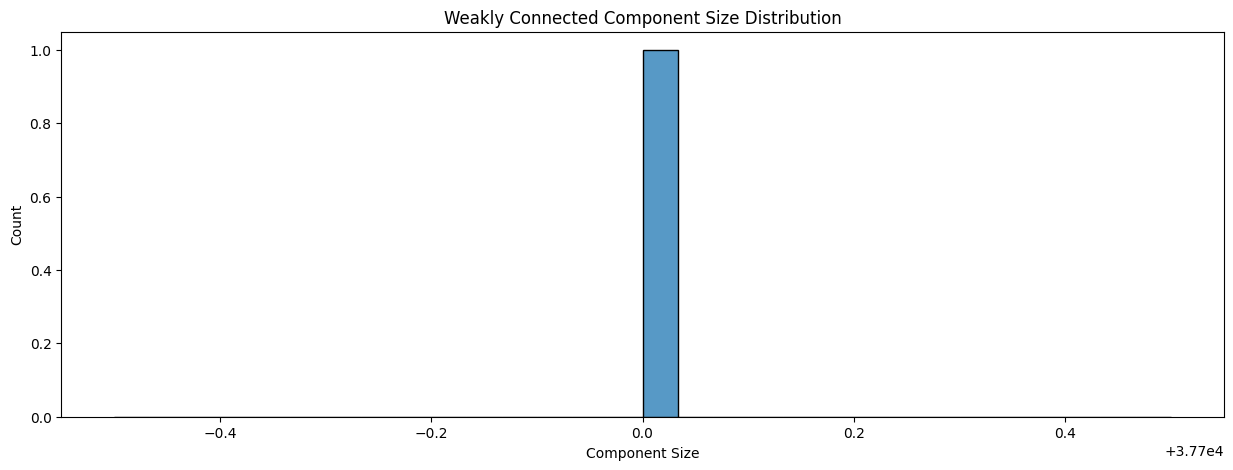

In [ ]:
weak_sizes = [len(c) for c in weak_components]

plt.figure(figsize=(15, 5))

sns.histplot(weak_sizes, bins=30)

plt.title("Weakly Connected Component Size Distribution")
plt.xlabel("Component Size")
plt.ylabel("Count")

plt.show()

# Clustering Coeficient

In [18]:
# Compute clustering coefficients and show distribution
G_und = G.to_undirected()

# Average clustering
avg_clustering = nx.average_clustering(G_und)

# Local clustering per node
clust_dict = nx.clustering(G_und)
df_clust = pd.DataFrame(
    {"node_id": list(clust_dict.keys()), "clustering": list(clust_dict.values())}
)

In [23]:
print(f"Average clustering (undirected): {avg_clustering:.4f}")

Average clustering (undirected): 0.1675


In [24]:
print(df_clust["clustering"].describe())

count    37700.000000
mean         0.167537
std          0.225168
min          0.000000
25%          0.000000
50%          0.100000
75%          0.226316
max          1.000000
Name: clustering, dtype: float64


In [27]:
# Fraction of nodes with zero clustering
zero_frac = (df_clust["clustering"] == 0).mean()
print(f"Fraction of nodes with clustering == 0: {zero_frac:.3f}")

Fraction of nodes with clustering == 0: 0.336


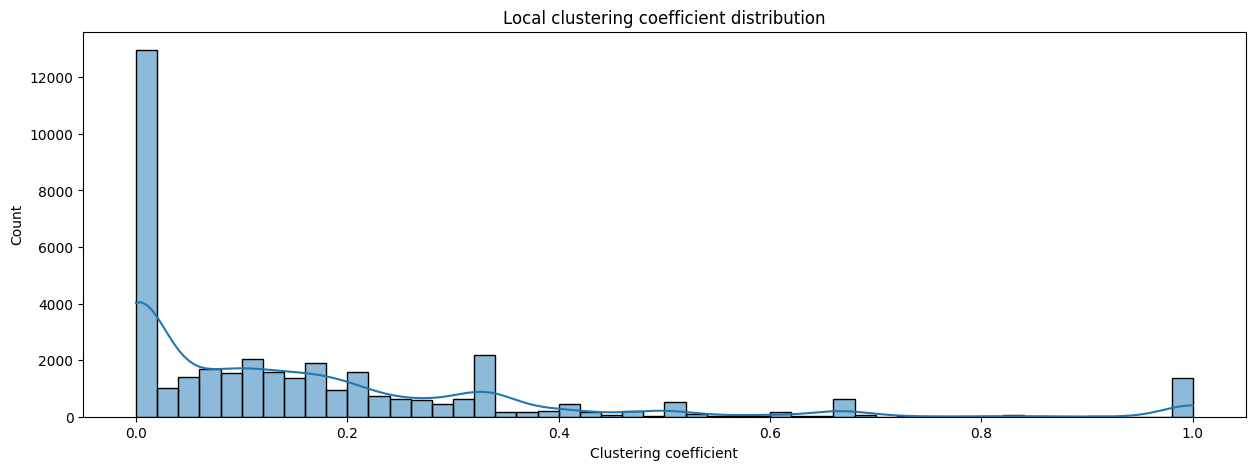

In [29]:
plt.figure(figsize=(15, 5))
sns.histplot(df_clust["clustering"], bins=50, kde=True)
plt.title("Local clustering coefficient distribution")
plt.xlabel("Clustering coefficient")
plt.ylabel("Count")
plt.show()

In [30]:
# Top nodes by clustering
top_clust = df_clust.sort_values("clustering", ascending=False).head(10)
print("Top 10 nodes by clustering:")
print(top_clust)

Top 10 nodes by clustering:
       node_id  clustering
25231    12270         1.0
37269    33935         1.0
37264    29154         1.0
37222    37625         1.0
37214    28891         1.0
37213    29924         1.0
37394    36302         1.0
37392    36222         1.0
37386    35929         1.0
37385    35925         1.0


In [31]:
# Nodes with zero clustering
zero_nodes = df_clust[df_clust["clustering"] == 0].sample(
    min(10, (df_clust["clustering"] == 0).sum()), random_state=42
)
print("Sample nodes with clustering == 0:")
print(zero_nodes)

Sample nodes with clustering == 0:
       node_id  clustering
10073    10426         0.0
33147    21353         0.0
24968    29690         0.0
25549    28937         0.0
36715    29862         0.0
24335    26903         0.0
37547     4507         0.0
37163    30840         0.0
25187    36185         0.0
5517      5046         0.0
